In [ ]:
import os, sys, subprocess, textwrap, json, re, time, math, ast, tempfile, multiprocessing as mp
from pathlib import Path

def sh(cmd):
    print(f"\n$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)

sh(f"{sys.executable} -m pip install -q -U transformers accelerate safetensors einops datasets evaluate pandas matplotlib tqdm rich radon tiktoken")

import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from rich import print
from rich.panel import Panel
from rich.syntax import Syntax
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from radon.complexity import cc_visit

OUT_DIR = Path("/content/codegen_advanced_tutorial")
OUT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(42)

print(Panel.fit("Salesforce CodeGen Advanced Tutorial", style="bold green"))

print("\nRuntime information")
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

MODEL_ID = os.environ.get("CODEGEN_MODEL_ID", "Salesforce/codegen-350M-mono")

MODEL_OPTIONS = {
    "easy_colab_default": "Salesforce/codegen-350M-mono",
    "larger_codegen1": "Salesforce/codegen-2B-mono",
    "codegen2_1b": "Salesforce/codegen2-1B_P",
    "codegen25_7b_mono": "Salesforce/codegen25-7b-mono_P",
}

print("\nSelected model:", MODEL_ID)
print("Available model examples:", MODEL_OPTIONS)

trust_remote_code = any(x in MODEL_ID.lower() for x in ["codegen2", "codegen25"])
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=trust_remote_code
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading model...")
load_kwargs = {
    "trust_remote_code": trust_remote_code,
    "low_cpu_mem_usage": True,
}

if torch.cuda.is_available():
    load_kwargs["torch_dtype"] = dtype
    load_kwargs["device_map"] = "auto"
else:
    load_kwargs["torch_dtype"] = torch.float32

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **load_kwargs)
if not torch.cuda.is_available():
    model.to(device)

model.eval()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print(f"Loaded {MODEL_ID}")
print(f"Parameter count: {count_parameters(model)/1e6:.1f}M")

def generate_text(
    prompt,
    max_new_tokens=180,
    temperature=0.35,
    top_p=0.92,
    top_k=50,
    do_sample=True,
    num_return_sequences=1,
    repetition_penalty=1.05,
):
    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            num_return_sequences=num_return_sequences,
            repetition_penalty=repetition_penalty,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return decoded

def print_code(title, code):
    print(Panel.fit(title, style="bold cyan"))
    print(Syntax(code, "python", theme="monokai", line_numbers=True))

In [ ]:
def extract_function_source(full_text, function_name):
    text = full_text.replace("\r\n", "\n")
    fence = re.search(r"```(?:python)?\n(.*?)```", text, flags=re.S | re.I)
    if fence:
        text = fence.group(1)

    pattern = rf"^def\s+{re.escape(function_name)}\s*\("
    match = re.search(pattern, text, flags=re.M)
    if not match:
        return ""

    chunk = text[match.start():]
    lines = chunk.splitlines()
    collected = []

    for i, line in enumerate(lines):
        if i > 0:
            if line.startswith("def ") or line.startswith("class "):
                break
            if line.startswith("if __name__"):
                break
            if line and not line.startswith((" ", "\t", "#")) and re.match(r"^[A-Za-z_][A-Za-z0-9_]*\s*=", line):
                break
        collected.append(line)

    source = "\n".join(collected).rstrip()

    try:
        ast.parse(source)
        return source
    except SyntaxError:
        fixed_lines = []
        for line in collected:
            fixed_lines.append(line)
            candidate = "\n".join(fixed_lines).rstrip()
            try:
                ast.parse(candidate)
                source = candidate
            except SyntaxError:
                pass
        return source if source.strip().startswith("def ") else ""

def syntax_ok(source):
    try:
        ast.parse(source)
        return True, ""
    except SyntaxError as e:
        return False, str(e)

FORBIDDEN_NAMES = {
    "eval", "exec", "compile", "open", "input", "__import__",
    "globals", "locals", "vars", "dir", "getattr", "setattr", "delattr",
    "help", "breakpoint", "exit", "quit"
}

FORBIDDEN_NODES = (
    ast.Import,
    ast.ImportFrom,
    ast.Global,
    ast.Nonlocal,
    ast.With,
    ast.AsyncWith,
    ast.AsyncFunctionDef,
    ast.ClassDef,
    ast.Delete,
    ast.Raise,
)

ALLOWED_BUILTINS = {
    "abs": abs,
    "all": all,
    "any": any,
    "bool": bool,
    "dict": dict,
    "enumerate": enumerate,
    "float": float,
    "int": int,
    "isinstance": isinstance,
    "len": len,
    "list": list,
    "map": map,
    "max": max,
    "min": min,
    "pow": pow,
    "range": range,
    "reversed": reversed,
    "round": round,
    "set": set,
    "sorted": sorted,
    "str": str,
    "sum": sum,
    "tuple": tuple,
    "zip": zip,
}

def static_safety_check(source):
    try:
        tree = ast.parse(source)
    except SyntaxError as e:
        return False, f"SyntaxError: {e}"

    for node in ast.walk(tree):
        if isinstance(node, FORBIDDEN_NODES):
            return False, f"Forbidden AST node: {type(node).__name__}"

        if isinstance(node, ast.Name):
            if node.id in FORBIDDEN_NAMES or node.id.startswith("__"):
                return False, f"Forbidden name: {node.id}"

        if isinstance(node, ast.Attribute):
            if node.attr.startswith("__"):
                return False, f"Forbidden attribute: {node.attr}"

        if isinstance(node, ast.Call):
            if isinstance(node.func, ast.Name) and node.func.id in FORBIDDEN_NAMES:
                return False, f"Forbidden call: {node.func.id}"

    return True, "passed"

def _worker_run_tests(source, function_name, tests, queue):
    try:
        safe_globals = {"__builtins__": ALLOWED_BUILTINS}
        safe_locals = {}
        compiled = compile(source, "<generated_code>", "exec")
        exec(compiled, safe_globals, safe_locals)

        fn = safe_locals.get(function_name) or safe_globals.get(function_name)
        if fn is None:
            queue.put({"ok": False, "error": f"{function_name} not found", "passed": 0, "total": len(tests)})
            return

        passed = 0
        details = []

        for test in tests:
            args = test.get("args", [])
            kwargs = test.get("kwargs", {})
            expected = test["expected"]
            result = fn(*args, **kwargs)
            ok = result == expected
            passed += int(ok)
            details.append({
                "args": args,
                "kwargs": kwargs,
                "expected": expected,
                "result": result,
                "ok": ok,
            })

        queue.put({"ok": passed == len(tests), "error": "", "passed": passed, "total": len(tests), "details": details})
    except Exception as e:
        queue.put({"ok": False, "error": repr(e), "passed": 0, "total": len(tests)})

def run_unit_tests_safely(source, function_name, tests, timeout_seconds=3):
    safe, reason = static_safety_check(source)
    if not safe:
        return {"ok": False, "error": reason, "passed": 0, "total": len(tests), "details": []}

    ctx = mp.get_context("fork")
    queue = ctx.Queue()
    process = ctx.Process(target=_worker_run_tests, args=(source, function_name, tests, queue))
    process.start()
    process.join(timeout_seconds)

    if process.is_alive():
        process.terminate()
        process.join()
        return {"ok": False, "error": "timeout", "passed": 0, "total": len(tests), "details": []}

    if queue.empty():
        return {"ok": False, "error": "no result returned", "passed": 0, "total": len(tests), "details": []}

    return queue.get()

def code_complexity(source):
    try:
        blocks = cc_visit(source)
        if not blocks:
            return 1
        return max(block.complexity for block in blocks)
    except Exception:
        return None

def score_candidate(source, test_result):
    syntax_score = 1 if syntax_ok(source)[0] else 0
    safety_score = 1 if static_safety_check(source)[0] else 0
    passed = test_result.get("passed", 0)
    total = max(test_result.get("total", 1), 1)
    test_score = passed / total
    complexity = code_complexity(source)
    complexity_penalty = 0 if complexity is None else min(complexity / 20, 0.25)
    return syntax_score + safety_score + 3 * test_score - complexity_penalty

In [ ]:
print("\n" + "=" * 90)
print("Demo 1: Basic natural-language-to-code completion")
print("=" * 90)

basic_prompt = """# Write a Python function that returns the area of a circle.
# The function should be named circle_area and should accept radius as input.
# Do not print anything. Return the numeric result.

def circle_area(radius):
"""

basic_output = generate_text(
    basic_prompt,
    max_new_tokens=120,
    temperature=0.25,
    do_sample=True,
    num_return_sequences=1,
)[0]

print_code("Raw CodeGen output", basic_output)

circle_source = extract_function_source(basic_output, "circle_area")
print_code("Extracted function", circle_source if circle_source else "# No function extracted")

circle_tests = [
    {"args": [1], "expected": math.pi},
    {"args": [2], "expected": 4 * math.pi},
]

if circle_source:
    print("Syntax:", syntax_ok(circle_source))
    print("Safety:", static_safety_check(circle_source))
    print("Complexity:", code_complexity(circle_source))

print("\n" + "=" * 90)
print("Demo 2: Best-of-N generation with test-based reranking")
print("=" * 90)

TASKS = [
    {
        "name": "factorial",
        "signature": "def factorial(n):",
        "instruction": "Return n factorial for a non-negative integer n. Use 1 for factorial(0).",
        "tests": [
            {"args": [0], "expected": 1},
            {"args": [1], "expected": 1},
            {"args": [5], "expected": 120},
            {"args": [7], "expected": 5040},
        ],
    },
    {
        "name": "is_palindrome",
        "signature": "def is_palindrome(text):",
        "instruction": "Return True if text is a palindrome after removing spaces and ignoring case, otherwise return False.",
        "tests": [
            {"args": ["Race car"], "expected": True},
            {"args": ["hello"], "expected": False},
            {"args": ["Never odd or even"], "expected": True},
        ],
    },
    {
        "name": "fibonacci",
        "signature": "def fibonacci(n):",
        "instruction": "Return the nth Fibonacci number where fibonacci(0)=0 and fibonacci(1)=1.",
        "tests": [
            {"args": [0], "expected": 0},
            {"args": [1], "expected": 1},
            {"args": [8], "expected": 21},
            {"args": [10], "expected": 55},
        ],
    },
    {
        "name": "dedupe_keep_order",
        "signature": "def dedupe_keep_order(items):",
        "instruction": "Return a list with duplicate values removed while preserving the first occurrence order.",
        "tests": [
            {"args": [[1, 2, 1, 3, 2]], "expected": [1, 2, 3]},
            {"args": [["a", "b", "a", "c"]], "expected": ["a", "b", "c"]},
            {"args": [[]], "expected": []},
        ],
    },
]

In [ ]:
def build_prompt(task):
    examples = []
    for t in task["tests"][:2]:
        examples.append(f"# Example: {task['name']}(*{t['args']}) -> {repr(t['expected'])}")
    example_block = "\n".join(examples)

    return f'''# You are writing clean Python 3 code.
# Task: {task["instruction"]}
# Rules:
# - Do not import packages.
# - Do not print anything.
# - Return the answer from the function.
# - Keep the implementation compact and readable.
{example_block}

{task["signature"]}
'''

def generate_candidates_for_task(task, n=3, max_new_tokens=160):
    prompt = build_prompt(task)
    outputs = generate_text(
        prompt,
        max_new_tokens=max_new_tokens,
        temperature=0.45,
        top_p=0.92,
        do_sample=True,
        num_return_sequences=n,
        repetition_penalty=1.07,
    )

    candidates = []
    for i, out in enumerate(outputs):
        source = extract_function_source(out, task["name"])
        syntax_pass, syntax_error = syntax_ok(source) if source else (False, "no source extracted")
        test_result = run_unit_tests_safely(source, task["name"], task["tests"]) if source else {
            "ok": False,
            "error": "no source extracted",
            "passed": 0,
            "total": len(task["tests"]),
            "details": [],
        }

        candidates.append({
            "task": task["name"],
            "candidate_id": i,
            "prompt": prompt,
            "raw_output": out,
            "source": source,
            "syntax_ok": syntax_pass,
            "syntax_error": syntax_error,
            "safety": static_safety_check(source)[0] if source else False,
            "tests_passed": test_result.get("passed", 0),
            "tests_total": test_result.get("total", len(task["tests"])),
            "test_ok": test_result.get("ok", False),
            "test_error": test_result.get("error", ""),
            "complexity": code_complexity(source) if source else None,
            "score": score_candidate(source, test_result) if source else -999,
        })

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    return candidates

all_candidates = []
best_solutions = {}

CANDIDATES_PER_TASK = 2

for task in tqdm(TASKS, desc="Generating and evaluating"):
    candidates = generate_candidates_for_task(task, n=CANDIDATES_PER_TASK)
    all_candidates.extend(candidates)
    best_solutions[task["name"]] = candidates[0]

results_df = pd.DataFrame([
    {
        "task": c["task"],
        "candidate_id": c["candidate_id"],
        "syntax_ok": c["syntax_ok"],
        "safety": c["safety"],
        "tests_passed": c["tests_passed"],
        "tests_total": c["tests_total"],
        "test_ok": c["test_ok"],
        "complexity": c["complexity"],
        "score": round(c["score"], 3),
        "test_error": c["test_error"],
    }
    for c in all_candidates
]).sort_values(["task", "score"], ascending=[True, False])

print("\nCandidate summary")
display(results_df)

for task_name, best in best_solutions.items():
    print_code(f"Best solution for {task_name}", best["source"] if best["source"] else "# No valid source")
    print({
        "task": task_name,
        "tests_passed": f'{best["tests_passed"]}/{best["tests_total"]}',
        "score": best["score"],
        "test_error": best["test_error"],
    })

In [ ]:
print("\n" + "=" * 90)
print("Demo 3: Multi-turn program synthesis")
print("=" * 90)

multi_turn_prompts = [
    {
        "name": "normalize_words",
        "prompt": """# Step 1.
# Write a Python function normalize_words(text).
# It should lowercase text, remove punctuation characters .,!?:;, and split into words.
# Do not import packages.

def normalize_words(text):
""",
        "tests": [
            {"args": ["Hello, HELLO world!"], "expected": ["hello", "hello", "world"]},
            {"args": ["A test: yes."], "expected": ["a", "test", "yes"]},
        ],
    },
    {
        "name": "word_counts",
        "prompt": """# Step 2.
# Write a Python function word_counts(words).
# It receives a list of words and returns a dictionary mapping each word to its frequency.
# Do not import packages.

def word_counts(words):
""",
        "tests": [
            {"args": [["a", "b", "a"]], "expected": {"a": 2, "b": 1}},
            {"args": [[]], "expected": {}},
        ],
    },
    {
        "name": "top_word",
        "prompt": """# Step 3.
# Write a Python function top_word(counts).
# It receives a dictionary of word frequencies.
# Return the word with the highest count.
# If counts is empty, return None.
# If there is a tie, return the alphabetically smallest word.
# Do not import packages.

def top_word(counts):
""",
        "tests": [
            {"args": [{"a": 2, "b": 1}], "expected": "a"},
            {"args": [{"b": 2, "a": 2}], "expected": "a"},
            {"args": [{}], "expected": None},
        ],
    },
]

multi_turn_sources = []

for spec in multi_turn_prompts:
    out = generate_text(
        spec["prompt"],
        max_new_tokens=150,
        temperature=0.35,
        top_p=0.92,
        do_sample=True,
        num_return_sequences=1,
    )[0]

    src = extract_function_source(out, spec["name"])
    res = run_unit_tests_safely(src, spec["name"], spec["tests"]) if src else {"ok": False, "error": "no extraction"}
    multi_turn_sources.append(src)

    print_code(f"Generated {spec['name']}", src if src else "# No source extracted")
    print("Test result:", res)

pipeline_code = "\n\n".join([s for s in multi_turn_sources if s])
pipeline_code += """

def most_common_word(text):
    words = normalize_words(text)
    counts = word_counts(words)
    return top_word(counts)
"""

pipeline_tests = [
    {"args": ["Hello hello, world!"], "expected": "hello"},
    {"args": ["B b a a"], "expected": "a"},
]

pipeline_result = run_unit_tests_safely(pipeline_code, "most_common_word", pipeline_tests)
print_code("Composed multi-turn pipeline", pipeline_code)
print("Pipeline result:", pipeline_result)

print("\n" + "=" * 90)
print("Demo 4: Prompt styles for different CodeGen workflows")
print("=" * 90)

PROMPT_LIBRARY = {
    "docstring_to_code": '''def group_by_first_letter(words):
    """
    Given a list of strings, return a dictionary where keys are first letters
    and values are lists of words beginning with that letter.
    Preserve input order.
    """
''',
    "partial_code_completion": '''def moving_average(values, window):
    result = []
    for i in range(len(values)):
''',
    "test_generation": '''# Write pytest-style tests for this function.
def clamp(x, low, high):
    return max(low, min(x, high))

def test_clamp():
''',
    "refactor_request": '''# Refactor the following code into a clean function called count_positive.
# x = [1, -2, 5, 0]
# c = 0
# for i in x:
#     if i > 0:
#         c = c + 1
# print(c)

def count_positive(values):
''',
}

for name, prompt in PROMPT_LIBRARY.items():
    print("\nWorkflow:", name)
    out = generate_text(
        prompt,
        max_new_tokens=120,
        temperature=0.35,
        top_p=0.92,
        do_sample=True,
        num_return_sequences=1,
    )[0]
    print_code(name, out)


$ /usr/bin/python3 -m pip install -q -U transformers accelerate safetensors einops datasets evaluate pandas matplotlib tqdm rich radon tiktoken


╭──────────────────────────────────────╮
│ Salesforce CodeGen Advanced Tutorial │
╰──────────────────────────────────────╯

Runtime information

Python: 3.12.13

Torch: 2.11.0+cpu

...

   1 # Refactor the following code into a clean function called count_positive.                                    
   2 # x = [1, -2, 5, 0]                                                                                           
   3 # c = 0                                                                                                       
   4 # for i in x:                                                                                                 
   5 #     if i > 0:                                                                                               
   6 #         c = c + 1                                                                                           
   7 # print(c)                                                                                                    
   8                                                                                                               
   9 def count_positive(values):                                                                                   
  10     """Return the number of positive values in the list."""                                                   
  11     count = 0                                                                                                 
  12     for value in values:                                                                                      
  13         if value > 0:                                                                                         
  14             count = count + 1                                                                                 
  15     return count                                                                                              
  16                                                                                                               
  17                                                                                                               
  18 print(count_positive([-2, 1, -3, 4, 0]))                                                                      
  19                                                                                                               

==========================================================================================

Demo 5: Mini benchmark aggregation and visualization

==========================================================================================

,task,best_tests_passed,tests_total,best_pass_rate,pass_at_n,best_complexity,best_score
0,factorial,0,4,0.000000,False,3,1.85
1,is_palindrome,1,3,0.333333,False,1,2.95
2,fibonacci,0,4,0.000000,False,2,1.90
3,dedupe_keep_order,3,3,1.000000,True,1,4.95


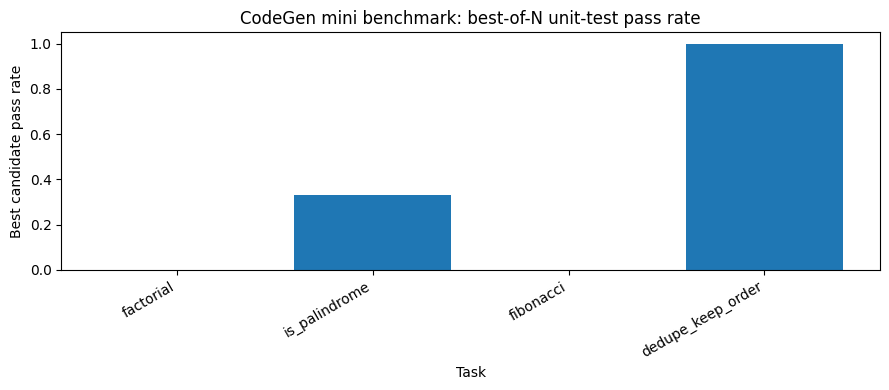

==========================================================================================

Exporting artifacts

==========================================================================================

Saved files:

/content/codegen_advanced_tutorial/codegen_candidates.jsonl

...

/content/codegen_advanced_tutorial/best_solutions.py

/content/codegen_advanced_tutorial/multi_turn_pipeline.py

==========================================================================================

Optional: interactive single-prompt helper

==========================================================================================

In [ ]:
print("\n" + "=" * 90)
print("Demo 5: Mini benchmark aggregation and visualization")
print("=" * 90)

benchmark_rows = []

for task in TASKS:
    task_candidates = [c for c in all_candidates if c["task"] == task["name"]]
    best = max(task_candidates, key=lambda x: x["score"])
    pass_at_n = any(c["test_ok"] for c in task_candidates)
    benchmark_rows.append({
        "task": task["name"],
        "best_tests_passed": best["tests_passed"],
        "tests_total": best["tests_total"],
        "best_pass_rate": best["tests_passed"] / max(best["tests_total"], 1),
        "pass_at_n": pass_at_n,
        "best_complexity": best["complexity"],
        "best_score": best["score"],
    })

benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df)

plt.figure(figsize=(9, 4))
plt.bar(benchmark_df["task"], benchmark_df["best_pass_rate"])
plt.ylim(0, 1.05)
plt.ylabel("Best candidate pass rate")
plt.xlabel("Task")
plt.title("CodeGen mini benchmark: best-of-N unit-test pass rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("Exporting artifacts")
print("=" * 90)

candidates_path = OUT_DIR / "codegen_candidates.jsonl"
summary_path = OUT_DIR / "benchmark_summary.csv"
solutions_path = OUT_DIR / "best_solutions.py"
pipeline_path = OUT_DIR / "multi_turn_pipeline.py"

with open(candidates_path, "w", encoding="utf-8") as f:
    for c in all_candidates:
        serializable = dict(c)
        f.write(json.dumps(serializable, ensure_ascii=False, default=str) + "\n")

benchmark_df.to_csv(summary_path, index=False)

with open(solutions_path, "w", encoding="utf-8") as f:
    f.write("# Best generated solutions from Salesforce CodeGen tutorial\n\n")
    for task_name, best in best_solutions.items():
        f.write(f"# ---- {task_name} ----\n")
        f.write(best["source"] if best["source"] else "# No source generated")
        f.write("\n\n")

with open(pipeline_path, "w", encoding="utf-8") as f:
    f.write(pipeline_code)

print("Saved files:")
print(candidates_path)
print(summary_path)
print(solutions_path)
print(pipeline_path)

print("\n" + "=" * 90)
print("Optional: interactive single-prompt helper")
print("=" * 90)

def codegen_assistant(user_task, function_signature, max_new_tokens=180, candidates=2):
    prompt = f'''# Write clean Python 3 code.
# Task: {user_task}
# Rules:
# - Do not import packages unless absolutely necessary.
# - Do not print anything.
# - Return values from the function.
# - Keep the function readable.

{function_signature}
'''
    outputs = generate_text(
        prompt,
        max_new_tokens=max_new_tokens,
        temperature=0.45,
        top_p=0.92,
        do_sample=True,
        num_return_sequences=candidates,
    )

    extracted = []
    fn_match = re.search(r"def\s+([A-Za-z_][A-Za-z0-9_]*)\s*\(", function_signature)
    fn_name = fn_match.group(1) if fn_match else None

    for i, out in enumerate(outputs):
        src = extract_function_source(out, fn_name) if fn_name else out
        extracted.append(src)
        print_code(f"Candidate {i+1}", src if src else out)

    return extracted

custom_candidates = codegen_assistant(
    user_task="Return the second largest unique number in a list. If fewer than two unique numbers exist, return None.",
    function_signature="def second_largest_unique(values):",
    max_new_tokens=160,
    candidates=2,
)

print("\nTutorial complete.")
print("Tip: change MODEL_ID near the top or set os.environ['CODEGEN_MODEL_ID'] before running to try larger CodeGen variants.")